### Basic ChatBot Using Langgraph agentic workflow

In [1]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages


In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]
    

In [3]:
import os 
from dotenv import load_dotenv

load_dotenv()


True

In [4]:
from langchain.chat_models import init_chat_model
from langchain_groq import ChatGroq

llm = init_chat_model("groq:llama-3.1-8b-instant")
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x10add8400>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10b019af0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [5]:
#creating a node chatbot imp: every node we have to create definition

def chatbot(state:State):
    return {"messages":llm.invoke(state["messages"])}



In [6]:
#creating the graph 
graphbuilder = StateGraph(State)

#adding node for graph 
graphbuilder.add_node("llmchatbot",chatbot)

#adding edges for graph 
graphbuilder.add_edge(START,"llmchatbot")
graphbuilder.add_edge("llmchatbot",END)

#compile the graph 
graph = graphbuilder.compile()



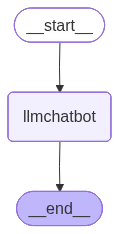

In [7]:
#visualisation of our graph to undrestanding how it is 

from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [8]:
response = graph.invoke({"messages":"Hi"})
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [9]:
#streaming methode we using 

for event in graph.stream({"messages":"Hi"}):
    # print(event)
    for val in event.values():
        print(val['messages'].content)


It's nice to meet you. Is there something I can help you with or would you like to chat?


### Chat bot tools setup

In [10]:
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=2)
tavily_tool.invoke("what is current gold price in india")

{'query': 'what is current gold price in india',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.goodreturns.in/gold-rates/',
   'title': 'Gold Rate Today (2 March 2026), Gold Price in India - Goodreturns',
   'content': 'The price of gold in India today is ₹17,051 per gram for 24 karat gold, ₹15,630 per gram for 22 karat gold and ₹12,788 per gram for 18 karat gold (also',
   'score': 0.92491204,
   'raw_content': None},
  {'url': 'https://www.muthootfinance.com/gold-rate-today',
   'title': 'Gold Rate Today in India - 22, 24 Carat Gold Price - Muthoot Finance',
   'content': 'Today 22 CT Gold Rate Per gram in India (INR) ; 1 gram, 16888.67, 16888.67 ; 8 gram, 135109.33, 135109.33 ; 10 gram, 168886.67, 168886.67 ; 100 gram, 1688866.67',
   'score': 0.86108357,
   'raw_content': None}],
 'response_time': 0.5,
 'request_id': 'e740dc39-7543-4f73-9106-5db7f4de9b94'}

In [11]:
#creating another tool we use doc string 

def multiply(a:int,b:int):
    """
    Summary:
    Multply two numbers and return the result.

    Parameters:
    a (int or float): First number
    b (int or float): Second number

    Returns:
    int or float: Multiply of a and b
    """
    return a*b
    

In [12]:
tools = [tavily_tool,multiply]
#binding the tools with llm

llm_with_tools = llm.bind_tools(tools)
llm_with_tools

RunnableBinding(bound=ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x10add8400>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10b019af0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a search query.', 'parameters': {'properties': {'query': {'description': 'Search query to look up', 'type': 'string'}, 'include_domains': {'anyOf': [{'items': {'type': 'string'}, 'type': 'array'}, {'type': 'null'}], 'default': [], 'description': 'A list of domai

In [13]:
#Node definition
def tool_calling_llm(state:State):
    return {"messages":llm_with_tools.invoke(state['messages'])}


In [14]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
#graph builder
tool_builder = StateGraph(State)
#Node definition
tool_builder.add_node('tool_calling_llm',tool_calling_llm)
#tool node definition
tool_builder.add_node("tools",ToolNode(tools))

#edges
tool_builder.add_edge(START,"tool_calling_llm")
tool_builder.add_conditional_edges(
    "tool_calling_llm",
    #if res need tool call it move tool node 
    #if response not calling tool call it move to END 
    tools_condition
)
tool_builder.add_edge("tools",END)

#compile the graph 

graph = tool_builder.compile()



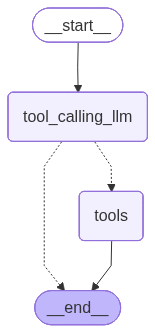

In [15]:
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [17]:
response = graph.invoke({"messages":"What is the current temperature in kondotty"})
response['messages']
for m in response['messages']:
    m.pretty_print()


================================ Human Message =================================

What is the current temperature in kondotty
================================== Ai Message ==================================
Tool Calls:
  tavily_search (29j2v6f5z)
 Call ID: 29j2v6f5z
  Args:
    query: current temperature in kondotty
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "current temperature in kondotty", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cbsnews.com/pittsburgh/news/meteorological-spring-2026-pittsburgh-weather-forecast/", "title": "Meteorological spring begins in Pittsburgh with sunshine and chillier temperatures - CBS News", "score": 0.03852772, "published_date": "Sun, 01 Mar 2026 12:37:13 GMT", "content": "# Meteorological spring begins in Pittsburgh with sunshine and chillier temperatures. This isn't the Spring Equinox, which is March 20th at 10:46 a.m.,

In [18]:
response = graph.invoke({"messages":"What is multiply 2 * 2"})
response['messages']
for m in response['messages']:
    m.pretty_print()


================================ Human Message =================================

What is multiply 2 * 2
================================== Ai Message ==================================
Tool Calls:
  multiply (pnxe8d9v4)
 Call ID: pnxe8d9v4
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: multiply

4


In [19]:
response = graph.invoke({"messages":"Hi How are u"})
response['messages']
for m in response['messages']:
    m.pretty_print()


================================ Human Message =================================

Hi How are u
================================== Ai Message ==================================

I'm functioning properly, thanks for asking.


In [21]:
response = graph.invoke({"messages":"Give the current gold rate and multiply by 2 * 4"})
response['messages']
for m in response['messages']:
    m.pretty_print()


================================ Human Message =================================

Give the current gold rate and multiply by 2 * 4
================================== Ai Message ==================================
Tool Calls:
  tavily_search (etejp0qs2)
 Call ID: etejp0qs2
  Args:
    query: Current gold rate
  multiply (mgwq52fh2)
 Call ID: mgwq52fh2
  Args:
    a: 2
    b: 4
================================= Tool Message =================================
Name: tavily_search

{"query": "Current gold rate", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://goldprice.org/gold-price-usa.html", "title": "Current Gold Price in USA", "content": "Current Gold Holdings. Amount. Weight. Ounce, Gram, Kilogram. Currency. USD, AED, ARS ... Price Of Gold in USA · Gold Price per Ounce: 5,351.87, +120.84. Gold", "score": 0.997851, "raw_content": null}, {"url": "https://www.livepriceofgold.com/new-york-gold-price.html", "title": "New York Gold Price Live - 24-hour 

### React Agent architecture(Real agentic ai architecture)

In [95]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
#graph builder
tool_builder = StateGraph(State)
#Node definition
tool_builder.add_node('tool_calling_llm',tool_calling_llm)
#tool node definition
tool_builder.add_node("tools",ToolNode(tools))

#edges
tool_builder.add_edge(START,"tool_calling_llm")
tool_builder.add_conditional_edges(
    "tool_calling_llm",
    #if res need tool call it move tool node 
    #if response not calling tool call it move to END 
    tools_condition
)
tool_builder.add_edge("tools","tool_calling_llm")

#compile the graph 

graph = tool_builder.compile()



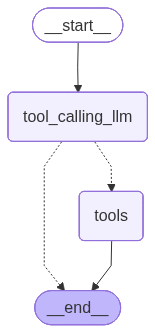

In [22]:
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [23]:
response = graph.invoke({"messages":"Give the current gold rate and multiply by 2 * 4"})
response['messages']
for m in response['messages']:
    m.pretty_print()
    

================================ Human Message =================================

Give the current gold rate and multiply by 2 * 4
================================== Ai Message ==================================
Tool Calls:
  tavily_search (ddt3xzsnv)
 Call ID: ddt3xzsnv
  Args:
    query: current gold rate
    search_depth: basic
    topic: finance
  multiply (ksk5cs2y7)
 Call ID: ksk5cs2y7
  Args:
    a: 2
    b: 4
================================= Tool Message =================================
Name: tavily_search

{"query": "current gold rate", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.forbes.com/advisor/investing/gold-price/", "title": "Gold Price Today: March 2, 2026 – Forbes Advisor", "content": "The price of gold today, as of 8:34 a.m. ET, was $5413.33 per ounce. That's up 2.57% over the past 24 hours. Compared to last week, the price of gold is up", "score": 0.7062922, "raw_content": null}, {"url": "https://www.bloomberg.com/mar

### Memory in langraph


In [32]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

#memory intiate 
memory = MemorySaver()
#graph builder
tool_builder = StateGraph(State)
#Node definition
tool_builder.add_node('tool_calling_llm',tool_calling_llm)
#tool node definition
tool_builder.add_node("tools",ToolNode(tools))

#edges
tool_builder.add_edge(START,"tool_calling_llm")
tool_builder.add_conditional_edges(
    "tool_calling_llm",
    #if res need tool call it move tool node 
    #if response not calling tool call it move to END 
    tools_condition
)
tool_builder.add_edge("tools","tool_calling_llm")

#compile the graph  during compile we add memeory 

graph = tool_builder.compile(checkpointer=memory)



In [33]:
#need to declare config to each memeroy thread to understand which thread include it is

config = {"configurable":{"thread_id":"1"}}

#during message we add corresponding config 
response = graph.invoke({"messages":"Hei my name is shafeer"},config=config)

for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hei my name is shafeer
================================== Ai Message ==================================

Hei Shafeer, hei! Nice to meet you. How can I help you today? Do you need to search for something or would you like to play a game?


In [34]:
#during message we add corresponding config 
response = graph.invoke({"messages":"Hei what is my name"},config=config)

for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hei my name is shafeer
================================== Ai Message ==================================

Hei Shafeer, hei! Nice to meet you. How can I help you today? Do you need to search for something or would you like to play a game?
================================ Human Message =================================

Hei what is my name
================================== Ai Message ==================================

Your name is Shafeer.


### Stream methode 
there is two stream is stream and asytrem it has two parameters 
Two parameters :
updates() 
values() 

In [35]:
for chunk in graph.stream({"messages":"Hi my name is shafeer i like to play "},config=config,stream_mode="updates"):
    print(chunk)

{'tool_calling_llm': {'messages': AIMessage(content="It seems like you started to type something but it got cut off. What would you like to play? We can play a text-based game, and I'll do my best to make it fun for you.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 43, 'prompt_tokens': 1981, 'total_tokens': 2024, 'completion_time': 0.065377643, 'completion_tokens_details': None, 'prompt_time': 0.135794852, 'prompt_tokens_details': None, 'queue_time': 0.051392887, 'total_time': 0.201172495}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--019cb865-ad8c-7dd1-b933-9f491566227d-0', usage_metadata={'input_tokens': 1981, 'output_tokens': 43, 'total_tokens': 2024})}}


In [36]:
for chunk in graph.stream({"messages":"i like to play football"},config=config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hei my name is shafeer', additional_kwargs={}, response_metadata={}, id='dd58b947-892a-404c-93d9-c86c2df61e2a'), AIMessage(content='Hei Shafeer, hei! Nice to meet you. How can I help you today? Do you need to search for something or would you like to play a game?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 1900, 'total_tokens': 1937, 'completion_time': 0.068857761, 'completion_tokens_details': None, 'prompt_time': 0.12043245, 'prompt_tokens_details': None, 'queue_time': 0.056684359, 'total_time': 0.189290211}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--019cb863-c84f-7c31-803d-96151327fce4-0', usage_metadata={'input_tokens': 1900, 'output_tokens': 37, 'total_tokens': 1937}), HumanMessage(content='Hei what is my name', additional_kwargs={}, response_metadata={}, id='1bd5f95a-1b15-48

In [38]:
config = {"configurable":{"thread_id":"2"}}
async for chunk in graph.astream_events({"messages":"Hi my name is shafeer i like to play "},config=config,stream_mode="updates"):
    print(chunk)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hi my name is shafeer i like to play '}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019cb868-8dde-7ce0-aba5-062c05a6d91c', 'metadata': {'thread_id': '2'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi my name is shafeer i like to play ', additional_kwargs={}, response_metadata={}, id='13b72364-d225-4ee6-a47b-c6c2258cf5ad')]}}, 'name': 'tool_calling_llm', 'tags': ['graph:step:1'], 'run_id': '019cb868-8de4-7130-92ef-d455951882f7', 'metadata': {'thread_id': '2', 'langgraph_step': 1, 'langgraph_node': 'tool_calling_llm', 'langgraph_triggers': ('branch:to:tool_calling_llm',), 'langgraph_path': ('__pregel_pull', 'tool_calling_llm'), 'langgraph_checkpoint_ns': 'tool_calling_llm:c0a0198e-cd21-4ffc-e93a-988b06e6321b'}, 'parent_ids': ['019cb868-8dde-7ce0-aba5-062c05a6d91c']}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi my name is shafeer i

### Human in the loop

In [62]:
from langgraph.prebuilt import ToolNode,tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

from langgraph.types import Command,interrupt



from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from langchain.chat_models import init_chat_model

from typing_extensions import TypedDict


memory = MemorySaver()

class State(TypedDict):
    messages:Annotated[list,add_messages]

graphbuilder = StateGraph(State)

@tool
def human_assitant(query:str) -> str:
    """ Request Assistant from a human."""
    human_response = interrupt({"query":query})
    return human_response["data"]

tavily_tool = TavilySearch(max_results=2)
tools = [tavily_tool,human_assitant]



llm = init_chat_model("groq:llama-3.1-8b-instant")

llm_with_tools = llm.bind_tools(tools)

def chatbot(state:State):
    messages = llm_with_tools.invoke(state['messages'])
    return {"messages":[messages]}

graphbuilder.add_node("chatbot",chatbot)
tool_node = ToolNode(tools=tools)
graphbuilder.add_node("tools",tool_node)

graphbuilder.add_edge(START,"chatbot")
graphbuilder.add_conditional_edges(
    "chatbot",
    tools_condition
)

graphbuilder.add_edge("tools","chatbot")

graph = graphbuilder.compile(checkpointer=memory)



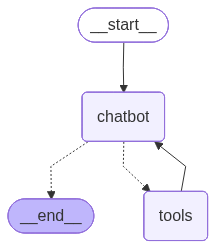

In [41]:
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [63]:
config = {'configurable':{"thread_id":"2"}}

user_input = "I need guidnace and assistance for building Ai agent.could you request assitance for me?"

events = graph.stream({"messages":user_input},config=config,stream_mode="values")

for event in events:
    if 'messages' in event:
        event['messages'][-1].pretty_print()
  
human_response = ("we ready to help you here from our side the best approach is learn ai agent is langchain "
                  "we apprciate you to build you ai agent ")
human_command = Command(resume={"data":human_response})
events = graph.stream(human_command,config=config,stream_mode="values")

for event in events:
    if 'messages' in event:
        event['messages'][-1].pretty_print()

================================ Human Message =================================

I need guidnace and assistance for building Ai agent.could you request assitance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assitant (rka9sp16f)
 Call ID: rka9sp16f
  Args:
    query: Request AI development assistance with building an AI agent.
================================== Ai Message ==================================
Tool Calls:
  human_assitant (rka9sp16f)
 Call ID: rka9sp16f
  Args:
    query: Request AI development assistance with building an AI agent.
================================= Tool Message =================================
Name: human_assitant

we ready to help you here from our side the best approach is learn ai agent is langchain we apprciate you to build you ai agent 
================================== Ai Message ==================================
Tool Calls:
  tavily_search (2ar8nyg7q)
 Call ID: 2ar8nyg7q
  Args:
    

================================== Ai Message ==================================
Tool Calls:
  human_assitant (x9rmet23z)
 Call ID: x9rmet23z
  Args:
    query: I need assistance with building an AI agent
  tavily_search (tfv3kmvre)
 Call ID: tfv3kmvre
  Args:
    query: building AI agent
    search_depth: advanced
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "building AI agent", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://medium.com/@neriasebastien/learning-how-to-build-ai-agents-7349f3821c3d", "title": "Learning How to Build AI Agents. My First No-Code Workflow", "content": "Building from there, autonomous agents can decide which steps and tools to use with minimal explicit instructions. While full autonomy remains an evolving capability rather than a fully realized one, we’re progressing rapidly.\n\nThe Four Building Blocks of AI Agents\n\nDrawing from bo

KeyboardInterrupt: 